# Import thư viện

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
from collections import Counter

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
custom_stopwords = {
    "said", "reuters", "ap", "s", "new",
    "say", "says", "would", "could", "also"
}

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

# Load data

In [15]:
train_path = "/content/train.csv"
test_path = "/content/test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

train_df.columns = train_df.columns.str.lower()
test_df.columns = test_df.columns.str.lower()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (120000, 3)
Test shape: (7600, 3)


,class index,title,description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


# EDA Chất lượng dữ liệu

## Check NULL và DUP

In [16]:
print("Missing values:\n", train_df.isnull().sum())

Missing values:
 class index    0
title          0
description    0
dtype: int64


In [17]:
content_duplicates = train_df.duplicated(subset=['title', 'description']).sum()
print(f"Số lượng trùng lặp nội dung: {content_duplicates}")

Số lượng trùng lặp nội dung: 0


In [18]:
train_df[train_df['description'].str.contains('""')]

,class index,title,description
3606,1,"Elmer Bernstein, Film Composer, Dead at 82","LOS ANGELES - Elmer Bernstein, the versatile, ..."
32089,1,"Emmys to Have New Look, Same Matchups",LOS ANGELES - The Emmy Awards will have a diff...
32521,1,Long-Running Shows to Take Final Emmys Bow,"LOS ANGELES - ""Frasier,""""Friends"" and ""Sex and..."
61768,3,"\$2,137,000 and Counting",David Gardner launches our Foolanthropy campai...
61785,1,Lucas to Receive AFI Lifetime Award,"LOS ANGELES - After creating ""Star Wars,""""Raid..."
63799,3,Biotech's 5 Baggers,How can yesterday's biotech winners lead you t...
70657,4,Wireless San Francisco,\\Reuters has a story about Gavin Newsom fina...
83585,4,Hello Canada!,"\\Reuters reports:\\""OTTAWA (Reuters) - The nu..."


- Lỗi dính từ (Missing Spaces): 3606, 32089, 32521, 61785
- Rác HTML/XML (HTML Tags Leakage): 61768, 63799
- Ký tự Escape và Backslash dư thừa: 70657, 83585

## Phân phối nhãn

class index
1    30000
2    30000
3    30000
4    30000
Name: count, dtype: int64

Percentage:
 class index
3    0.25
4    0.25
2    0.25
1    0.25
Name: proportion, dtype: float64


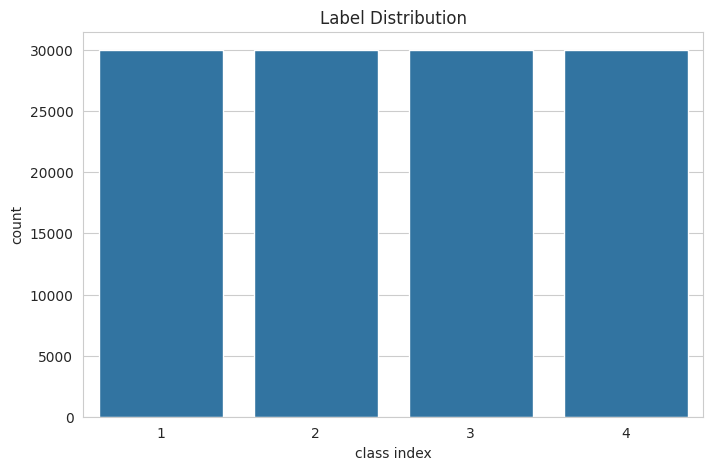

In [19]:
label_counts = train_df['class index'].value_counts().sort_index()

print(label_counts)
print("\nPercentage:\n", train_df['class index'].value_counts(normalize=True))

sns.countplot(x='class index', data=train_df)
plt.title("Label Distribution")
plt.show()

## Conat Titles and Discriptions

In [20]:
train_df['text'] = train_df['title'] + ' ' + train_df['description']
test_df['text'] = test_df['title'] + ' ' + test_df['description']

train_df.head()

,class index,title,description,text
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Wall St. Bears Claw Back Into the Black (Reute...
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Carlyle Looks Toward Commercial Aerospace (Reu...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Oil and Economy Cloud Stocks' Outlook (Reuters...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,Iraq Halts Oil Exports from Main Southern Pipe...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...","Oil prices soar to all-time record, posing new..."


## Text length features

--- THỐNG KÊ CHIỀU DÀI VĂN BẢN ---
mean     37.844617
50%      37.000000
min       4.000000
max     177.000000
Name: word_count, dtype: float64

--- NGƯỠNG CẮT (PERCENTILES) ---
90% bài báo có độ dài <= 48 từ
95% bài báo có độ dài <= 53 từ
99% bài báo có độ dài <= 70 từ


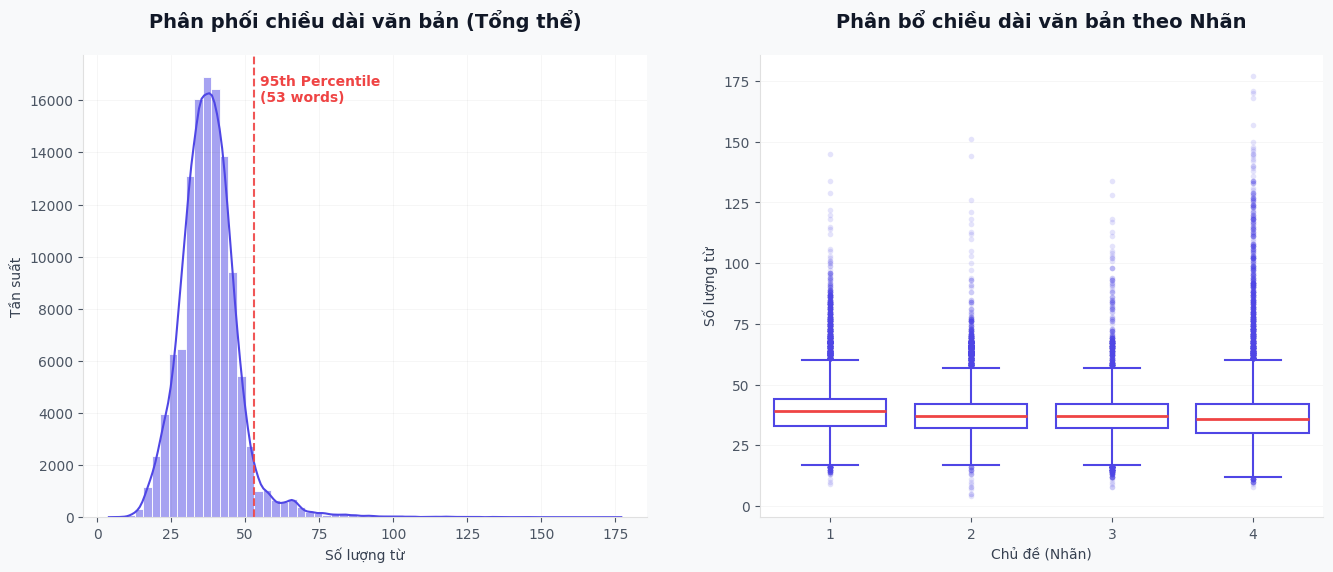

In [21]:
# ---------------------------------------------------------
# 1. TÍNH TOÁN SỐ TỪ BẰNG VECTOR HÓA (Tối ưu tốc độ)
# ---------------------------------------------------------
train_df['word_count'] = train_df['text'].str.split().str.len()

# ---------------------------------------------------------
# 2. TRÍCH XUẤT THỐNG KÊ MÔ TẢ & TÌM NGƯỠNG CẮT (CUT-OFF)
# ---------------------------------------------------------
print("--- THỐNG KÊ CHIỀU DÀI VĂN BẢN ---")
print(train_df['word_count'].describe()[['mean', '50%', 'min', 'max']])

p90 = train_df['word_count'].quantile(0.90)
p95 = train_df['word_count'].quantile(0.95)
p99 = train_df['word_count'].quantile(0.99)

print("\n--- NGƯỠNG CẮT (PERCENTILES) ---")
print(f"90% bài báo có độ dài <= {p90:.0f} từ")
print(f"95% bài báo có độ dài <= {p95:.0f} từ")
print(f"99% bài báo có độ dài <= {p99:.0f} từ")

# ---------------------------------------------------------
# 3. TRỰC QUAN HÓA PHÂN PHỐI (Modern Light Minimalist)
# ---------------------------------------------------------
# Khôi phục cài đặt mặc định để xóa nền đen trước đó
plt.style.use('default')

# Tạo figure với nền màu xám rất nhạt, tạo cảm giác dịu mắt
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='#F8F9FA')
fig.subplots_adjust(wspace=0.2)

# Xóa viền trên và phải, làm nhạt viền dưới/trái và lưới (zero clutter)
for ax in axes:
    ax.set_facecolor('#FFFFFF') # Lòng đồ thị màu trắng tinh
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#E0E0E0')
    ax.spines['bottom'].set_color('#E0E0E0')
    ax.grid(color='#000000', alpha=0.05, linestyle='-', linewidth=0.5)

    # Định dạng lại màu chữ cho hài hòa
    ax.tick_params(colors='#4B5563')
    ax.xaxis.label.set_color('#374151')
    ax.yaxis.label.set_color('#374151')

# Biểu đồ 1: Histogram phân phối độ dài toàn tập dữ liệu
sns.histplot(data=train_df, x='word_count', bins=60, kde=True,
             color='#4F46E5', edgecolor='#FFFFFF', ax=axes[0])

# Vẽ đường phân vị 95th bằng màu đỏ để làm nổi bật trên nền sáng
axes[0].axvline(p95, color='#EF4444', linestyle='--', linewidth=1.5, alpha=0.9)
axes[0].text(p95 + 2, axes[0].get_ylim()[1]*0.9, f'95th Percentile\n({p95:.0f} words)',
             color='#EF4444', fontweight='bold')

axes[0].set_title('Phân phối chiều dài văn bản (Tổng thể)', pad=20, fontsize=14, color='#111827', fontweight='bold')
axes[0].set_xlabel('Số lượng từ')
axes[0].set_ylabel('Tần suất')

# Biểu đồ 2: Boxplot kiểm tra sự phân tán theo từng nhãn cụ thể
sns.boxplot(data=train_df, x='class index', y='word_count',
            color='#FFFFFF',
            boxprops=dict(edgecolor='#4F46E5', linewidth=1.5),
            whiskerprops=dict(color='#4F46E5', linewidth=1.5),
            capprops=dict(color='#4F46E5', linewidth=1.5),
            medianprops=dict(color='#EF4444', linewidth=2), # Đường trung vị màu đỏ
            flierprops=dict(marker='o', markerfacecolor='#4F46E5', markersize=4, alpha=0.15, markeredgecolor='none'),
            ax=axes[1])

axes[1].set_title('Phân bổ chiều dài văn bản theo Nhãn', pad=20, fontsize=14, color='#111827', fontweight='bold')
axes[1].set_xlabel('Chủ đề (Nhãn)')
axes[1].set_ylabel('Số lượng từ')

plt.show()

## Text cleaning

In [22]:
def clean(text):
    if pd.isna(text):
        return ""
    text = text.lower()

    # bỏ ký tự đặc biệt
    text = re.sub(r'[^a-z ]', '', text)

    words = text.split()

    # remove stopwords + custom
    words = [
        w for w in words
        if w not in ENGLISH_STOP_WORDS
        and w not in custom_stopwords
        and len(w) > 2
    ]

    return " ".join(words)

train_df['clean_desc'] = train_df['text'].apply(clean)

## Top words (Toàn cục và từng class)

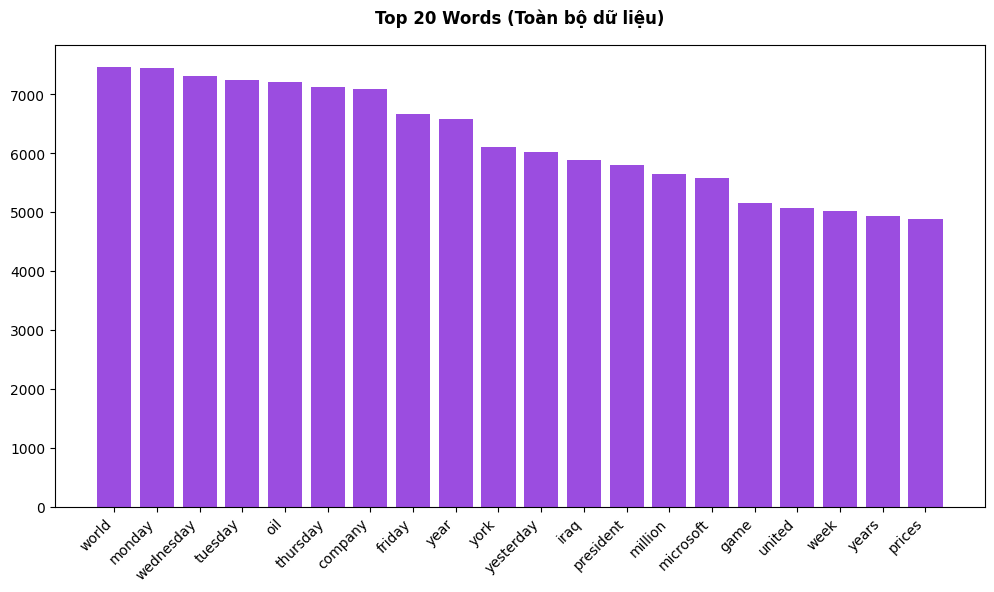

In [23]:
all_words = " ".join(train_df['clean_desc']).split()
common_words = Counter(all_words).most_common(20)

words, counts = zip(*common_words)

plt.figure(figsize=(12,6))
plt.bar(words, counts, color='#9B4DE0')
plt.xticks(rotation=45, ha='right')
plt.title("Top 20 Words (Toàn bộ dữ liệu)", pad=15, fontweight='bold')
plt.show()

**The class ids are numbered 1-4 where 1 represents World, 2 represents Sports, 3 represents Business and 4 represents Sci/Tech.**

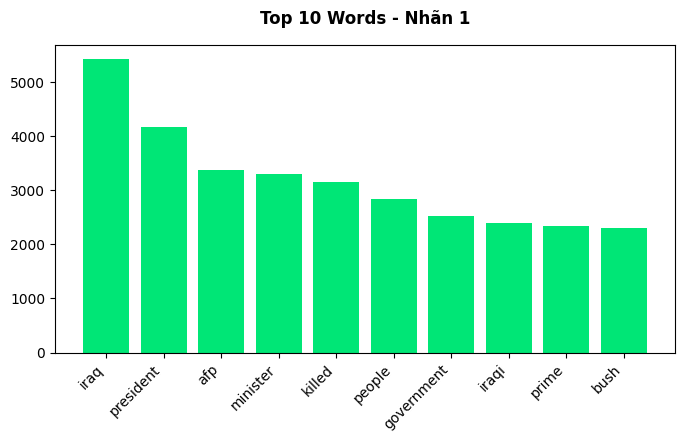

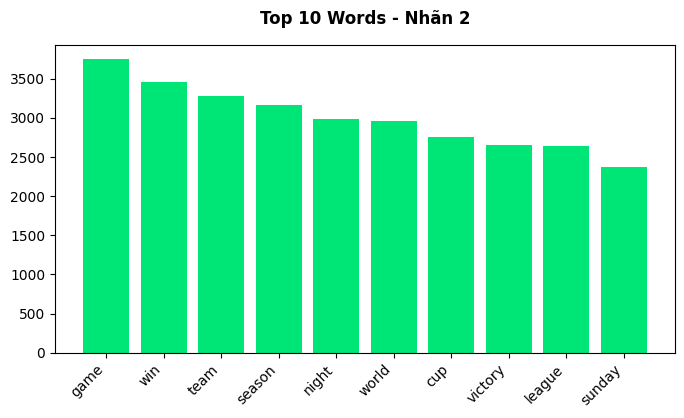

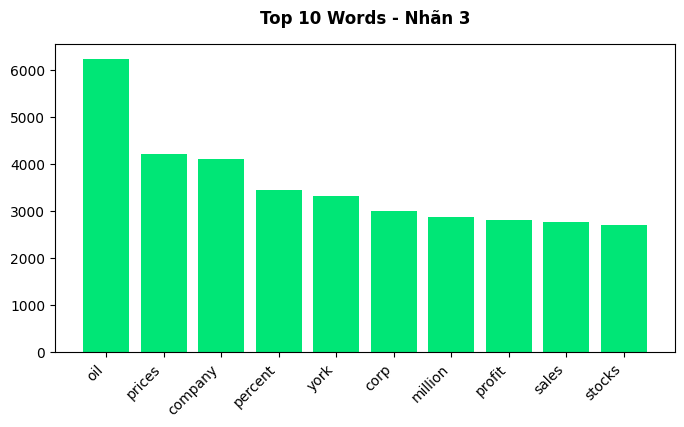

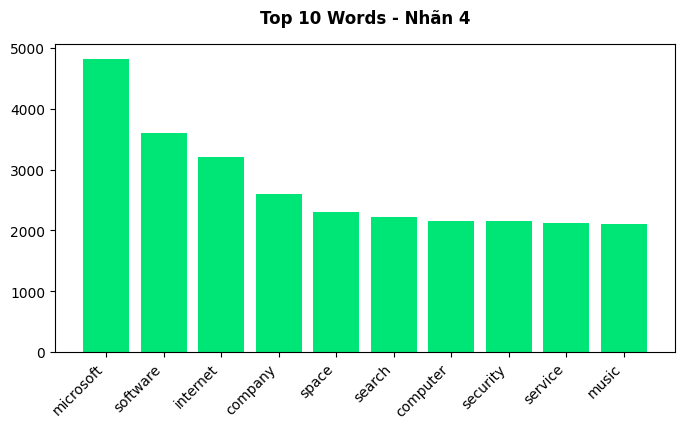

In [24]:
for label in sorted(train_df['class index'].unique()):
    words_cls = " ".join(train_df[train_df['class index']==label]['clean_desc']).split()
    common_cls = Counter(words_cls).most_common(10)
    w_cls, c_cls = zip(*common_cls)

    plt.figure(figsize=(8,4))
    plt.bar(w_cls, c_cls, color='#00E676')
    plt.title(f"Top 10 Words - Nhãn {label}", pad=15, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.show()

## Bigram

In [25]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(2,2), max_features=20)
X = vectorizer.fit_transform(train_df['clean_desc'])

bigram_counts = np.asarray(X.sum(axis=0)).flatten()
bigrams = vectorizer.get_feature_names_out()

bigram_df = pd.DataFrame({
    "bigram": bigrams,
    "count": bigram_counts
}).sort_values(by="count", ascending=False)

print(bigram_df)

              bigram  count
7         oil prices   2775
16     united states   2480
9     prime minister   2388
0            afp afp   1955
12           red sox   1500
13     san francisco   1292
14    sports network   1255
2    chief executive   1142
17       wall street   1122
5        los angeles   1033
11     quote profile   1023
10  profile research   1021
8     president bush    989
1     canadian press    910
15    united nations    893
18         world cup    837
6     microsoft corp    796
4     european union    774
3          crude oil    716
19         years ago    705


## Check leak giữa train và test

In [26]:
train_set = set(train_df['text'])
test_set = set(test_df['text'])

overlap = train_set.intersection(test_set)

print("Number of overlapping samples:", len(overlap))

Number of overlapping samples: 0


# Kết luận

## 📌 Kết luận – EDA cho bài toán phân loại tin tức

Quá trình EDA trên bộ dữ liệu gồm **120.000 mẫu train** và **7.600 mẫu test** đã cung cấp những hiểu biết quan trọng, làm cơ sở vững chắc cho các bước tiền xử lý và xây dựng mô hình phân loại.

### 1. Chất lượng dữ liệu
- **Không có giá trị khuyết (missing values)** trong cả 3 trường: `class index`, `title`, `description`. ✅
- **Không có sự trùng lặp (exact duplicates)** giữa các mẫu trong tập train. ✅
- **Không có rò rỉ dữ liệu (data leakage)** giữa tập train và test (giao bằng 0). ✅
- Dữ liệu có chất lượng tốt, sạch ở mức cơ bản và sẵn sàng cho xử lý tiếp.

### 2. Cấu trúc và phân phối dữ liệu
- **Các lớp (classes 1–4) được phân phối cân bằng tuyệt đối (25% mỗi lớp).**  
  Điều này rất thuận lợi: không cần xử lý mất cân bằng, có thể sử dụng `accuracy` hoặc `macro F1` làm metric đánh giá chính.

- **Độ dài văn bản (số từ) có phân phối tập trung:**
  - Trung bình: ~38 từ
  - Trung vị: 37 từ
  - 95% bài viết có ≤ 53 từ
  - 99% bài viết có ≤ 70 từ
  - Bài dài nhất: 177 từ

  ➡️ Đây là **tín hiệu rất quan trọng** cho việc chọn độ dài đầu vào (sequence length) trong các mô hình deep learning và BERT.

### 3. Phát hiện và xử lý lỗi dữ liệu
Qua kiểm tra thủ công, chúng tôi phát hiện và ghi nhận một số dạng lỗi cần được làm sạch trước khi đưa vào mô hình:

| Loại lỗi | Ví dụ | Ảnh hưởng |
|----------|-------|-------------|
| Dính từ (missing spaces) | `"Frasier""Friends"`, `"Star Wars""Raiders"` | Làm sai tokenization |
| Rác HTML/XML | `<meta name="keywords"...` | Nhiễu thông tin |
| Ký tự escape dư thừa | `\\Reuters`, `\\"OTTAWA` | Gây nhiễu token |
| Ký tự đặc biệt, số, dấu câu | `$2,137,000`, `5 Baggers` | Có thể quan trọng tùy model |


### 4. Đặc trưng ngôn ngữ và từ khóa
- **Top từ toàn cục** bao gồm các từ như `said`, `reuters`, `oil`, `president`, `percent`, `billion` → phản ánh đúng bối cảnh tin tức kinh tế, chính trị.
- **Top từ theo từng lớp** cho thấy khả năng phân biệt rõ ràng giữa các chủ đề:
  - **World (class 1):** `iraq`, `president`, `bush`, `united nations`
  - **Sports (class 2):** `game`, `win`, `sox`, `red sox`, `coach`
  - **Business (class 3):** `oil`, `prices`, `market`, `percent`, `billion`
  - **Sci/Tech (class 4):** `microsoft`, `corp`, `space`, `launch`, `software`

- **Bigram nổi bật** bao gồm `oil prices`, `united states`, `prime minister`, `red sox`, `wall street` → rất giàu ý nghĩa phân loại.

### 5. Kế hoạch phát triển
- **Các bước tiếp theo:**  
  1. Clean nhẹ dữ liệu.
  2. Tiền xử lý dữ liệu theo từng hướng mô hình (mức độ làm sạch khác nhau).  
  3. Xây dựng baseline cho từng nhánh.  
  4. Đánh giá và so sánh kết quả.

- **Quy trình linh hoạt:**  
  Trong quá trình xây dựng mô hình, nếu phát hiện vấn đề (ví dụ: model nhầm class nào đó, tokenization lỗi, hiệu năng kém), chúng tôi hoàn toàn có thể **quay lại EDA** để phân tích sâu hơn đúng phần cần thiết, bổ sung thêm insight để cải thiện mô hình. Đây là một **vòng lặp phát triển chuyên nghiệp**, không phải EDA một lần duy nhất.

---

✅ **Kết luận chung:**  
Dữ liệu sạch, cân bằng, có cấu trúc rõ ràng, không có vấn đề nghiêm trọng. Các insight từ EDA đã cung cấp đủ thông tin để bắt đầu xây dựng mô hình. Kế hoạch chia làm 3 nhánh là phù hợp. Nhóm sẵn sàng cho bước tiếp theo.

---
> *Ghi chú: Notebook này có thể được mở rộng với các phân tích sâu hơn (confusion matrix, feature importance, OOV rate, token distribution cho BERT) khi cần thiết trong quá trình phát triển mô hình.*